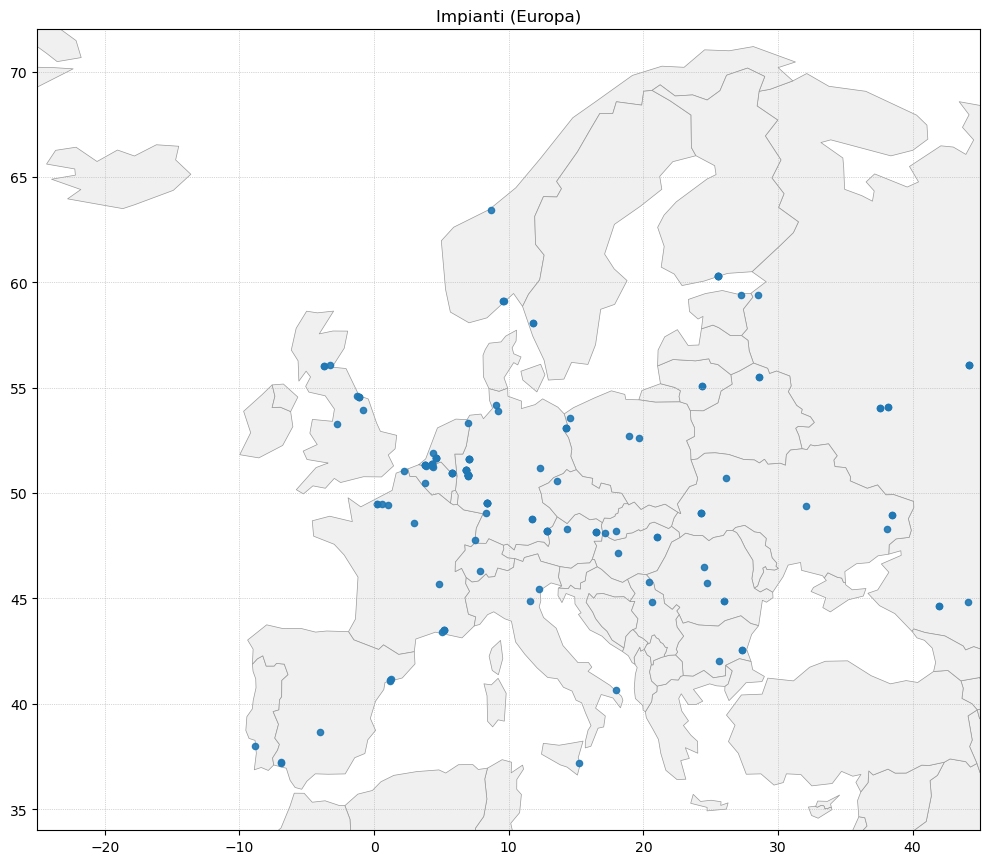

In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

# --- dati ---
plants = pd.read_excel("data/SFI_ALD_Petrochemicals_Sample_EU_NA_Apr_2022.xlsx",
                       sheet_name="SFI_ALD_Petrochemicals_EUNA")
europe = plants[plants['region'] == 'Europe'].dropna(subset=['latitude','longitude']).copy()

gdf = gpd.GeoDataFrame(
    europe,
    geometry=gpd.points_from_xy(europe['longitude'], europe['latitude']),
    crs="EPSG:4326"
)

# --- base map: Natural Earth via URL (S3 mirror) ---
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

# bounding box Europa approx (lon_min, lat_min, lon_max, lat_max)
bbox = (-25, 34, 45, 72)
world_eu = world.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]
gdf_eu   = gdf.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]

# --- plot ---
fig, ax = plt.subplots(figsize=(10, 10))
world_eu.plot(ax=ax, color="#f0f0f0", edgecolor="#999999", linewidth=0.5)
gdf_eu.plot(ax=ax, markersize=20, alpha=0.9)
ax.set_title("Impianti (Europa)")
ax.set_xlim(bbox[0], bbox[2]); ax.set_ylim(bbox[1], bbox[3])
ax.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout(); plt.show()


In [2]:
# Filter data on European plants for column 'country' == 'Netherlands', 'Belgium', 'Luxembourg' or 'Germany'
selected_countries = ['Netherlands', 'Belgium', 'Luxembourg', 'Germany']

# keep selected countries, and for Germany require state == 'North Rhine-Westphalia'
mask_countries = europe['country'].isin(selected_countries)
mask_germany_nrw = (europe['country'] == 'Germany') & ((europe['state'] == 'North Rhine-Westphalia'))
mask = mask_countries & ((europe['country'] != 'Germany') | mask_germany_nrw)
europe_filtered = europe[mask].copy()
chemicals = ['Ethylene', 'Propylene', 'Ammonia', 'Methanol']
mask_chemicals = europe_filtered['petrochemical'].isin(chemicals)
europe_filtered = europe_filtered[mask_chemicals].copy()

Mappa salvata come 'plants_map.png'
Mappa salvata come 'plants_map_clusters.png'


C:\Users\alessandro.magnino\AppData\Local\Temp\ipykernel_33208\2693986915.py:129: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((x, y), RADIUS/2, color=color, alpha=0.8, edgecolor='white', linewidth=0.6, zorder=3)


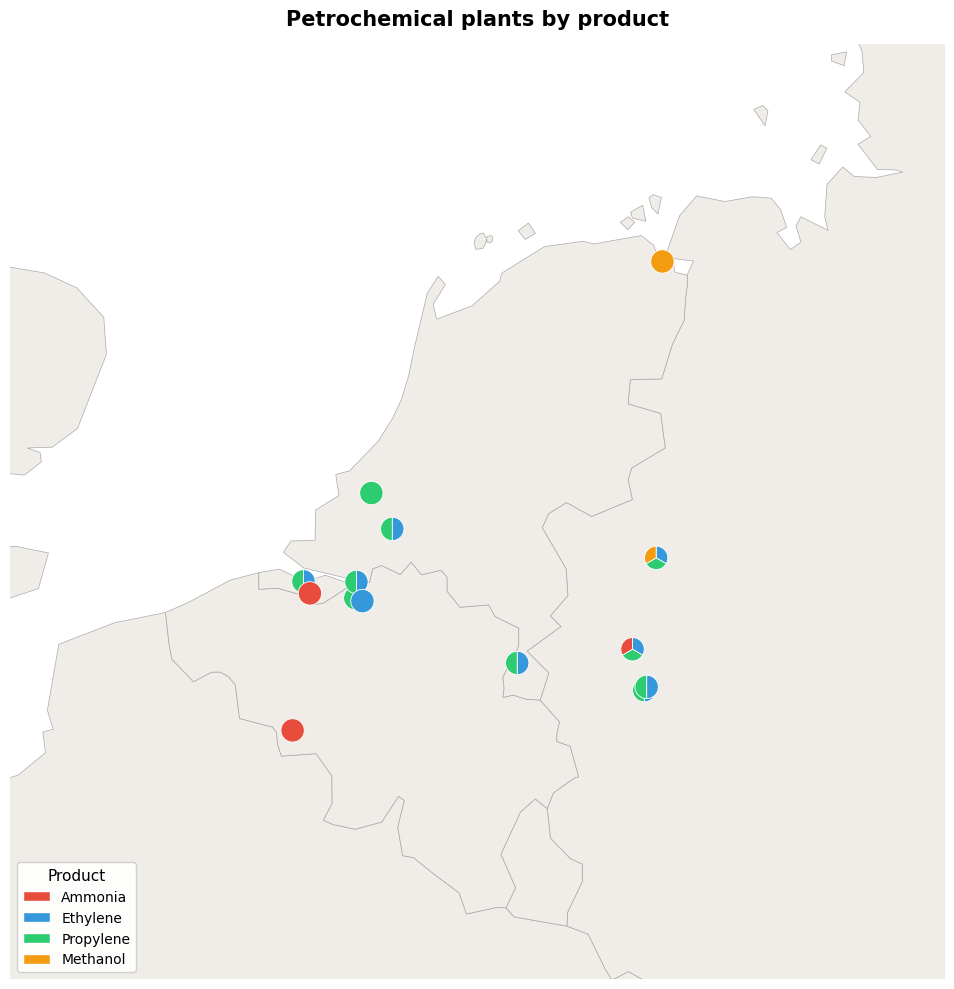

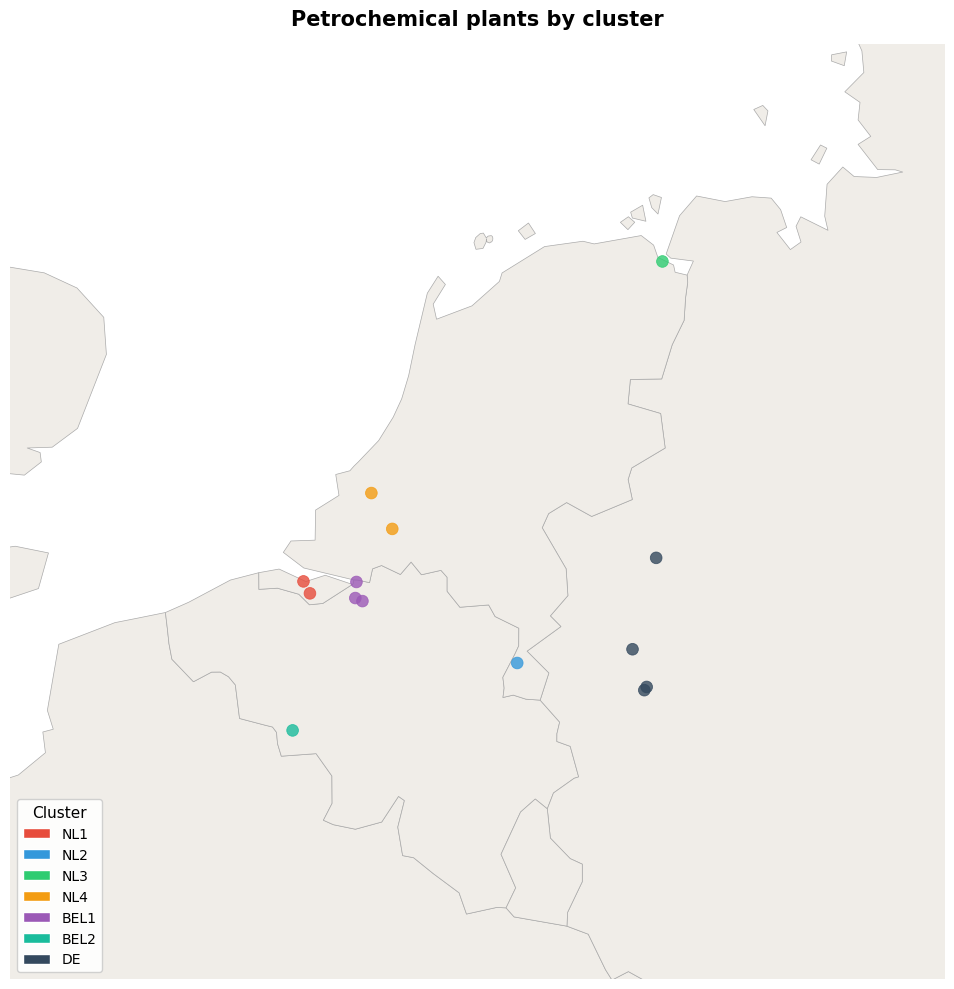

: 

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from shapely.geometry import Point
import numpy as np

# Filter data on European plants for column 'country' == 'Netherlands', 'Belgium', 'Luxembourg' or 'Germany'
selected_countries = ['Netherlands', 'Belgium', 'Luxembourg', 'Germany']

# keep selected countries, and for Germany require state == 'North Rhine-Westphalia'
mask_countries = europe['country'].isin(selected_countries)
mask_germany_nrw = (europe['country'] == 'Germany') & ((europe['state'] == 'North Rhine-Westphalia'))
mask = mask_countries & ((europe['country'] != 'Germany') | mask_germany_nrw)
europe_filtered = europe[mask].copy()
chemicals = ['Ethylene', 'Propylene', 'Ammonia', 'Methanol']
mask_chemicals = europe_filtered['petrochemical'].isin(chemicals)
europe_filtered = europe_filtered[mask_chemicals].copy()

prodotti = ['Ammonia', 'Ethylene', 'Propylene', 'Methanol']
clusters = ['NL1', 'NL2', 'NL3', 'NL4', 'BEL1', 'BEL2', 'DE']
europe_filtered_by_product = europe_filtered[europe_filtered['petrochemical'].isin(prodotti)].copy()
europe_filtered_by_cluster = europe_filtered[europe_filtered['Cluster'].isin(clusters)].copy()

colori = {
    'Ammonia':   '#e74c3c',
    'Ethylene':  '#3498db',
    'Propylene': '#2ecc71',
    'Methanol':  '#f39c12',
}

colors_for_clusters = {
    'NL1': '#e74c3c',
    'NL2': '#3498db',
    'NL3': '#2ecc71',
    'NL4': '#f39c12',
    'BEL1': '#9b59b6',
    'BEL2': '#1abc9c',
    'DE': '#34495e',
}

# Converti in GeoDataFrame e reproietta in EPSG:3035
gdf_plants = gpd.GeoDataFrame(
    europe_filtered_by_product,
    geometry=[Point(lon, lat) for lon, lat in zip(europe_filtered_by_product['longitude'], europe_filtered_by_product['latitude'])],
    crs='EPSG:4326'
).to_crs('EPSG:3035')

gdf_plants['x'] = gdf_plants.geometry.x
gdf_plants['y'] = gdf_plants.geometry.y

# --- Carica i confini NUTS livello 0 ---
nuts = gpd.read_file(r'data\NUTS_RG_20M_2016_3035.shp.zip')
countries = nuts[nuts['LEVL_CODE'] == 0].copy()

xmin, ymin, xmax, ymax = 3_700_000, 2_900_000, 4_300_000, 3_500_000
countries = countries.cx[xmin:xmax, ymin:ymax]

# --- Figura ---
fig, ax = plt.subplots(figsize=(12, 10))

countries.plot(
    ax=ax,
    color='#f0ede8',
    edgecolor='#aaaaaa',
    linewidth=0.5
)

# --- Disegna gli spicchi ---
# Raggruppa per posizione esatta (stesso impianto, prodotti diversi)
RADIUS = 7500  # raggio in metri (EPSG:3035); regola a piacere

for (x, y), group in gdf_plants.groupby(['x', 'y']):
    prods = group['petrochemical'].tolist()
    n = len(prods)
    angle_step = 360 / n
    start_angle = 90  # parte dall'alto, gira in senso antiorario

    for prod in prods:
        wedge = Wedge(
            center=(x, y),
            r=RADIUS,
            theta1=start_angle - angle_step,
            theta2=start_angle,
            facecolor=colori[prod],
            edgecolor='white',
            linewidth=0.6,
            zorder=3
        )
        ax.add_patch(wedge)
        start_angle -= angle_step

# --- Legenda manuale ---
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(facecolor=colori[p], edgecolor='white', label=p)
    for p in prodotti
]
ax.legend(
    handles=legend_handles,
    title='Product',
    title_fontsize=11,
    fontsize=10,
    loc='lower left',
    framealpha=0.9
)

# --- Estetica ---
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title('Petrochemical plants by product', fontsize=15, fontweight='bold', pad=14)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('data/plants_map.png', dpi=150, bbox_inches='tight')
print("Mappa salvata come 'plants_map.png'")

# --- Plot con cluster ---
fig, ax = plt.subplots(figsize=(12, 10))
countries.plot(
    ax=ax,
    color='#f0ede8',
    edgecolor='#aaaaaa',
    linewidth=0.5
)
for (x, y), group in gdf_plants.groupby(['x', 'y']):
    cluster = group['Cluster'].iloc[0]  # assumiamo che tutti i prodotti dello stesso impianto appartengano allo stesso cluster
    color = colors_for_clusters.get(cluster, '#000000')  # nero se cluster sconosciuto
    circle = plt.Circle((x, y), RADIUS/2, color=color, alpha=0.8, edgecolor='white', linewidth=0.6, zorder=3)
    ax.add_patch(circle)
legend_handles = [
    mpatches.Patch(facecolor=colors_for_clusters[c], edgecolor='white',
                        label=c) for c in clusters  ]
ax.legend(
    handles=legend_handles,
    title='Cluster',
    title_fontsize=11,
    fontsize=10,
    loc='lower left',
    framealpha=0.9
)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title('Petrochemical plants by cluster', fontsize=15, fontweight='bold', pad=14)
ax.set_axis_off()
plt.tight_layout()
# plt.savefig('data/plants_map_clusters.png', dpi=150, bbox_inches='tight')
print("Mappa salvata come 'plants_map_clusters.png'")


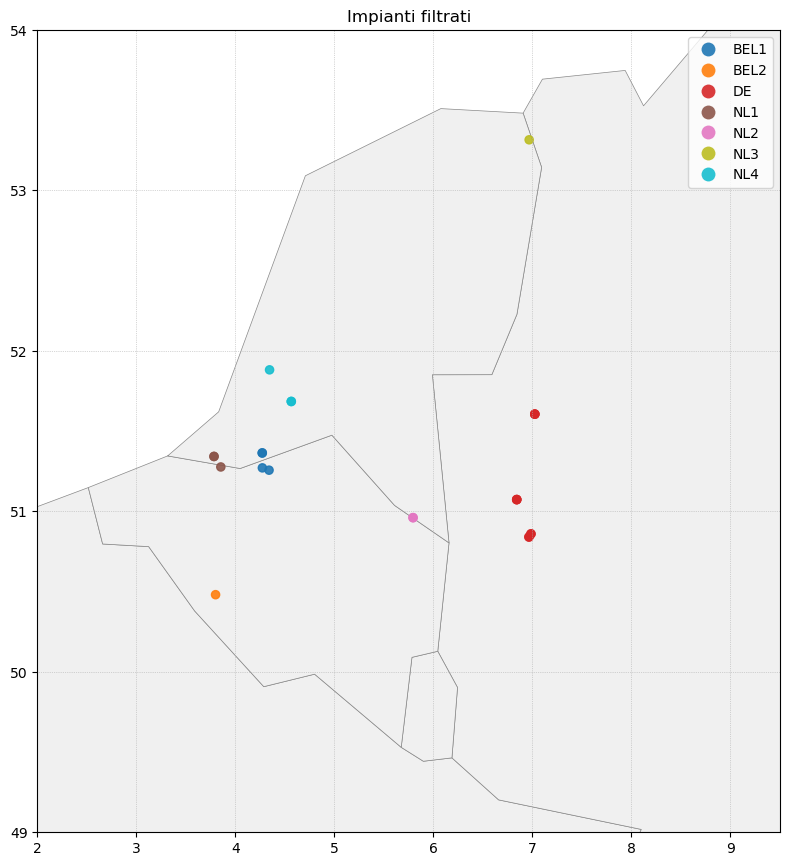

In [3]:
# pip install geopandas shapely matplotlib
import geopandas as gpd
import matplotlib.pyplot as plt

df = europe_filtered.dropna(subset=["latitude","longitude"]).copy()
# assicurati che 'petrochemical' sia di tipo categorico
df["petrochemical"] = df["petrochemical"].fillna("Unknown").astype("category")
# assicurati che 'cluster' sia di tipo categorico
df["Cluster"] = df["Cluster"].fillna("Unknown").astype("category")

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)

# Base map Natural Earth
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

# ROI: Benelux + NRW (lon_min, lat_min, lon_max, lat_max)
bbox = (2.0, 49.0, 9.5, 54.0)
world_roi = world.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]
gdf_roi   = gdf.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]

fig, ax = plt.subplots(figsize=(8, 9))
world_roi.plot(ax=ax, color="#f0f0f0", edgecolor="#888888", linewidth=0.5)

# colore per categoria: usa direttamente la colonna
gdf_roi.plot(
    ax=ax,
    column="Cluster",
    categorical=True,
    legend=True,
    markersize=35,
    alpha=0.9
)

ax.set_title("Impianti filtrati", fontsize=12)
ax.set_xlim(bbox[0], bbox[2]); ax.set_ylim(bbox[1], bbox[3])
ax.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout(); plt.show()



In [4]:
# Filter columns that we need
europe_filtered = europe_filtered[[
    'uid', 'country','latitude', 'longitude',
    'petrochemical', 'capacity', 'Cluster'
]]
# add column 'altitude' with value 0 for all rows
europe_filtered['altitude'] = 0

Cluster plants as unified units according to Cluter column

In [ ]:
rows = []

for cluster in europe_filtered['Cluster'].unique():
    cluster_data = europe_filtered[europe_filtered['Cluster'] == cluster]
    latitude = round(cluster_data['latitude'].mean(), 6) # crop to 6 decimals
    longitude = round(cluster_data['longitude'].mean(), 6) # crop to 6 decimals
    altitude = round(cluster_data['altitude'].mean(), 1) # crop to 1 decimal

    ammonia_capacity = cluster_data.loc[cluster_data['petrochemical'] == 'Ammonia', 'capacity'].sum()
    ethylene_capacity = cluster_data.loc[cluster_data['petrochemical'] == 'Ethylene', 'capacity'].sum()
    propylene_capacity = cluster_data.loc[cluster_data['petrochemical'] == 'Propylene', 'capacity'].sum()
    methanol_capacity = cluster_data.loc[cluster_data['petrochemical'] == 'Methanol', 'capacity'].sum()

    rows.append({
        'cluster': cluster,
        'country': cluster_data['country'].mode()[0],
        'latitude': latitude,
        'longitude': longitude,
        'altitude': altitude,
        'ammonia': ammonia_capacity,
        'ethylene': ethylene_capacity,
        'propylene': propylene_capacity,
        'methanol': methanol_capacity
    })

cluster_df = pd.DataFrame(rows, columns=['cluster', 'country', 'latitude', 'longitude', 'altitude', 'ammonia', 'ethylene', 'propylene', 'methanol'])

# save results to CSV
cluster_df.to_csv("data/plants_clusters_summary.csv", index=False)

In [ ]:
import numpy as np
import pandas as pd

# Average radius of the Earth in kilometers
EARTH_RADIUS_KM = 6371.0088

def pairwise_haversine(lat, lon, radius_km=EARTH_RADIUS_KM):
    """
    Calculate the matrix of pairwise Haversine distances between points.
    lat, lon: arrays of shape (N,) with latitude and longitude in degrees.
    Returns: array (N, N) with distances in km (diagonal = 0).
    """
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)
    # in radianti
    lat_rad = np.deg2rad(lat)
    lon_rad = np.deg2rad(lon)

    # broadcasting
    dlat = lat_rad[:, None] - lat_rad[None, :]
    dlon = lon_rad[:, None] - lon_rad[None, :]

    a = np.sin(dlat/2.0)**2 + np.cos(lat_rad)[:, None] * np.cos(lat_rad)[None, :] * np.sin(dlon/2.0)**2
    c = 2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))

    return radius_km * c


def distance_matrix(locations):
    """
    locations: DataFrame with columns [uid, latitude, longitude]
    Returns:

    """
    lat = locations["latitude"].to_numpy()
    lon = locations["longitude"].to_numpy()
    D = pairwise_haversine(lat, lon)
    idx = locations.index

    return pd.DataFrame(D, index=idx, columns=idx)


# Data
df = pd.read_csv("data/plants_clusters_summary.csv")[['cluster','latitude','longitude']].set_index('cluster')
distance_df = distance_matrix(df)   # DataFrame NxN con etichette
# convert to int
distance_df = distance_df.round().astype(int)
print(distance_df)

# Save to CSV
distance_df.to_csv("data/plants_distance_matrix.csv", sep=';')

cluster  BEL1  BEL2   DE  NL1  NL3  NL4  NL2
cluster                                     
BEL1        0    99  186   33  288   51  112
BEL2       99     0  233   93  383  149  150
DE        186   233    0  220  242  183   83
NL1        33    93  220    0  309   67  144
NL3       288   383  242  309    0  242  274
NL4        51   149  183   67  242    0  126
NL2       112   150   83  144  274  126    0
